<a href="https://colab.research.google.com/github/SunAhKim0430/parrot/blob/master/chapter4_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=cd06331f483fc8a239bcbc1bed1cb6813f3fbcde7ee9912a0de5e3500e5ea36e
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict, get_dataset_config_names, load_dataset
from huggingface_hub import notebook_login
from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.nn.functional import cross_entropy
from transformers import (
    AutoConfig,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    XLMRobertaForTokenClassification,
)

In [3]:
# =========================
# 4.1 데이터셋
# =========================

# XTREME 서브셋 확인
xtreme_subsets = get_dataset_config_names("xtreme")
print(f"XTREME 서브셋 개수: {len(xtreme_subsets)}")

panx_subsets = [s for s in xtreme_subsets if s.startswith("PAN")]
print(panx_subsets[:3])

# 독일어 PAN-X 로드
load_dataset("xtreme", name="PAN-X.de")

# 스위스 언어 비율 기반 샘플링
langs = ["de", "fr", "it", "en"]
fracs = [0.629, 0.229, 0.084, 0.059]

# 키가 없는 경우 DatasetDict를 반환합니다.
panx_ch = defaultdict(DatasetDict)

for lang, frac in zip(langs, fracs):
    # 다국어 말뭉치를 로드합니다.
    ds = load_dataset("xtreme", name=f"PAN-X.{lang}")
    # 각 분할을 언어 비율에 따라 다운샘플링하고 섞습니다.
    for split in ds:
        panx_ch[lang][split] = (
            ds[split]
            .shuffle(seed=0)
            .select(range(int(frac * ds[split].num_rows)))
        )

print(
    pd.DataFrame(
        {lang: [panx_ch[lang]["train"].num_rows] for lang in langs},
        index=["Number of training examples"],
    )
)

element = panx_ch["de"]["train"][0]
for key, value in element.items():
    print(f"{key}: {value}")

for key, value in panx_ch["de"]["train"].features.items():
    print(f"{key}: {value}")

tags = panx_ch["de"]["train"].features["ner_tags"].feature
print(tags)


def create_tag_names(batch):
    return {"ner_tags_str": [tags.int2str(idx) for idx in batch["ner_tags"]]}


panx_de = panx_ch["de"].map(create_tag_names)

de_example = panx_de["train"][0]
print(pd.DataFrame([de_example["tokens"], de_example["ner_tags_str"]], ["Tokens", "Tags"]))

split2freqs = defaultdict(Counter)
for split, dataset in panx_de.items():
    for row in dataset["ner_tags_str"]:
        for tag in row:
            if tag.startswith("B"):
                tag_type = tag.split("-")[1]
                split2freqs[split][tag_type] += 1

print(pd.DataFrame.from_dict(split2freqs, orient="index"))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

XTREME 서브셋 개수: 183
['PAN-X.af', 'PAN-X.ar', 'PAN-X.bg']


PAN-X.de/train-00000-of-00001.parquet:   0%|          | 0.00/1.18M [00:00<?, ?B/s]

PAN-X.de/validation-00000-of-00001.parqu(…):   0%|          | 0.00/590k [00:00<?, ?B/s]

...

                                de    fr    it    en
Number of training examples  12580  4580  1680  1180
tokens: ['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.']
ner_tags: [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]
langs: ['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de']
tokens: List(Value('string'))
ner_tags: List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']))
langs: List(Value('string'))
ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'])


Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

           0           1   2    3         4      5   6    7           8   \
Tokens  2.000  Einwohnern  an  der  Danziger  Bucht  in  der  polnischen   
Tags        O           O   O    O     B-LOC  I-LOC   O    O       B-LOC   

                  9        10 11  
Tokens  Woiwodschaft  Pommern  .  
Tags           B-LOC    I-LOC  O  
             LOC   ORG   PER
train       6186  5366  5810
validation  3172  2683  2893
test        3180  2573  3071


In [4]:
# =========================
# 4.3 XLM-R 토큰화
# =========================
bert_model_name = "bert-base-cased"
xlmr_model_name = "xlm-roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

text = "Jack Sparrow loves New York!"
bert_tokens = bert_tokenizer(text).tokens()
xlmr_tokens = xlmr_tokenizer(text).tokens()

print("BERT tokens:", bert_tokens)
print("XLM-R tokens:", xlmr_tokens)

print("".join(xlmr_tokens).replace(u"\u2581", " "))


# =========================
# 4.5 사용자 정의 토큰 분류 모델
# =========================
index2tag = {idx: tag for idx, tag in enumerate(tags.names)}
tag2index = {tag: idx for idx, tag in enumerate(tags.names)}

xlmr_config = AutoConfig.from_pretrained(
    xlmr_model_name,
    num_labels=tags.num_classes,
    id2label=index2tag,
    label2id=tag2index,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
xlmr_model = (
    XLMRobertaForTokenClassification
    .from_pretrained(xlmr_model_name, config=xlmr_config)
    .to(device)
)

input_ids = xlmr_tokenizer.encode(text, return_tensors="pt")
print(
    pd.DataFrame(
        [xlmr_tokens, input_ids[0].numpy()],
        index=["Tokens", "Input IDs"],
    )
)

outputs = xlmr_model(input_ids.to(device)).logits
predictions = torch.argmax(outputs, dim=-1)
print(f"시퀀스에 맞은 토큰 개수: {len(predictions[0])}")
print(f"출력 텐서 크기: {outputs.shape}")

preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
print(pd.DataFrame([xlmr_tokens, preds], index=["Tokens", "Tags"]))


def tag_text(text, tags, model, tokenizer):
    # 토큰을 준비합니다.
    tokens = tokenizer(text).tokens()
    # 시퀀스를 입력 ID로 변환합니다.
    input_ids = xlmr_tokenizer(text, return_tensors="pt").input_ids.to(device)
    # 가능한 타입 개수 출력을 먼저 보겠습니다.
    outputs = model(input_ids)[0]
    # argmax 함수로 토큰마다 가장 가능성이 높은 클래스를 선택합니다.
    predictions = torch.argmax(outputs, dim=2)
    # ID 배열과 태그명으로 변환합니다.
    preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
    return pd.DataFrame([tokens, preds], index=["Tokens", "Tags"])


# =========================
# 4.6 NER 작업을 위해 텍스트 토큰화하기
# =========================

# function(examples: Dict[str, List]) -> Dict[str, List]

# 예시 샘플 확인
words, labels = de_example["tokens"], de_example["ner_tags"]
print(words, labels)

tokenized_input = xlmr_tokenizer(de_example["tokens"], is_split_into_words=True)
tokens = xlmr_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
print(pd.DataFrame([tokens], index=["Tokens"]))

word_ids = tokenized_input.word_ids()
print(pd.DataFrame([tokens, word_ids], index=["Tokens", "Word IDs"]))

previous_word_idx = None
label_ids = []

for word_idx in word_ids:
    if word_idx is None or word_idx == previous_word_idx:
        label_ids.append(-100)
    elif word_idx != previous_word_idx:
        label_ids.append(labels[word_idx])
    previous_word_idx = word_idx

labels_str = [index2tag[l] if l != -100 else "IGN" for l in label_ids]
index = ["Tokens", "Word IDs", "Label IDs", "Labels"]
print(pd.DataFrame([tokens, word_ids, label_ids, labels_str], index=index))


def tokenize_and_align_labels(examples):
    tokenized_inputs = xlmr_tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    labels = []
    for idx, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


def encode_panx_dataset(corpus):
    return corpus.map(
        tokenize_and_align_labels,
        batched=True,
        remove_columns=["langs", "ner_tags", "tokens"],
    )


panx_de_encoded = encode_panx_dataset(panx_ch["de"])



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


             0      1      2      3      4  5     6      7   8     9
Tokens     <s>  ▁Jack  ▁Spar    row  ▁love  s  ▁New  ▁York   !  </s>
Input IDs    0  21763  37456  15555   5161  7  2356   5753  38     2
시퀀스에 맞은 토큰 개수: 10
출력 텐서 크기: torch.Size([1, 10, 7])
            0      1      2      3      4  5      6      7      8      9
Tokens    <s>  ▁Jack  ▁Spar    row  ▁love  s   ▁New  ▁York      !   </s>
Tags    I-PER  I-PER  I-PER  I-PER  I-PER  O  I-PER  I-PER  I-PER  I-PER
['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.'] [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]
         0       1           2  3    4     5     6   7    8      9   ...   15  \
Tokens  <s>  ▁2.000  ▁Einwohner  n  ▁an  ▁der  ▁Dan  zi  ger  ▁Buch  ...  ▁Wo   

       16   17      18   19    20 21 22 23    24  
Tokens  i  wod  schaft  ▁Po  mmer  n  ▁  .  </s>  

[1 rows x 25 columns]
            0       1           2  3    4     5     6   7    8      9   ...  \
To

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

              precision    recall  f1-score   support

        MISC       0.00      0.00      0.00         1
         PER       1.00      1.00      1.00         1

   micro avg       0.50      0.50      0.50         2
   macro avg       0.50      0.50      0.50         2
weighted avg       0.50      0.50      0.50         2



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

         0      1    2      3      4      5           6      7      8   \
Tokens  <s>  ▁Jeff  ▁De     an   ▁ist   ▁ein  ▁Informati    ker   ▁bei   
Tags      O      O    O  I-LOC  I-LOC  I-LOC       I-LOC  I-LOC  I-LOC   

             9    10          11     12    13  
Tokens  ▁Google  ▁in  ▁Kaliforni     en  </s>  
Tags      I-LOC    O       I-LOC  I-LOC     O  


Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

                                           input_ids  \
0                 [0, 10699, 11, 15, 16104, 1388, 2]   
1  [0, 56530, 25216, 30121, 152385, 19229, 83982,...   
2  [0, 159093, 165, 38506, 122, 153080, 29088, 57...   
3     [0, 16459, 242, 5106, 6, 198715, 5106, 242, 2]   
4  [0, 11022, 2315, 7418, 1079, 8186, 57242, 97, ...   

                                      attention_mask  \
0                              [1, 1, 1, 1, 1, 1, 1]   
1  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   
2         [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]   
3                        [1, 1, 1, 1, 1, 1, 1, 1, 1]   
4  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   

                                              labels  \
0        [IGN, B-ORG, IGN, I-ORG, I-ORG, I-ORG, IGN]   
1  [IGN, O, IGN, IGN, IGN, IGN, B-ORG, IGN, IGN, ...   
2  [IGN, O, O, O, O, B-ORG, IGN, IGN, O, IGN, O, ...   
3              [IGN, O, O, O, B-LOC, IGN, O, O, IGN]   
4  [IGN, O, O, O, O, O, O, O, IGN, O, O, O, B-

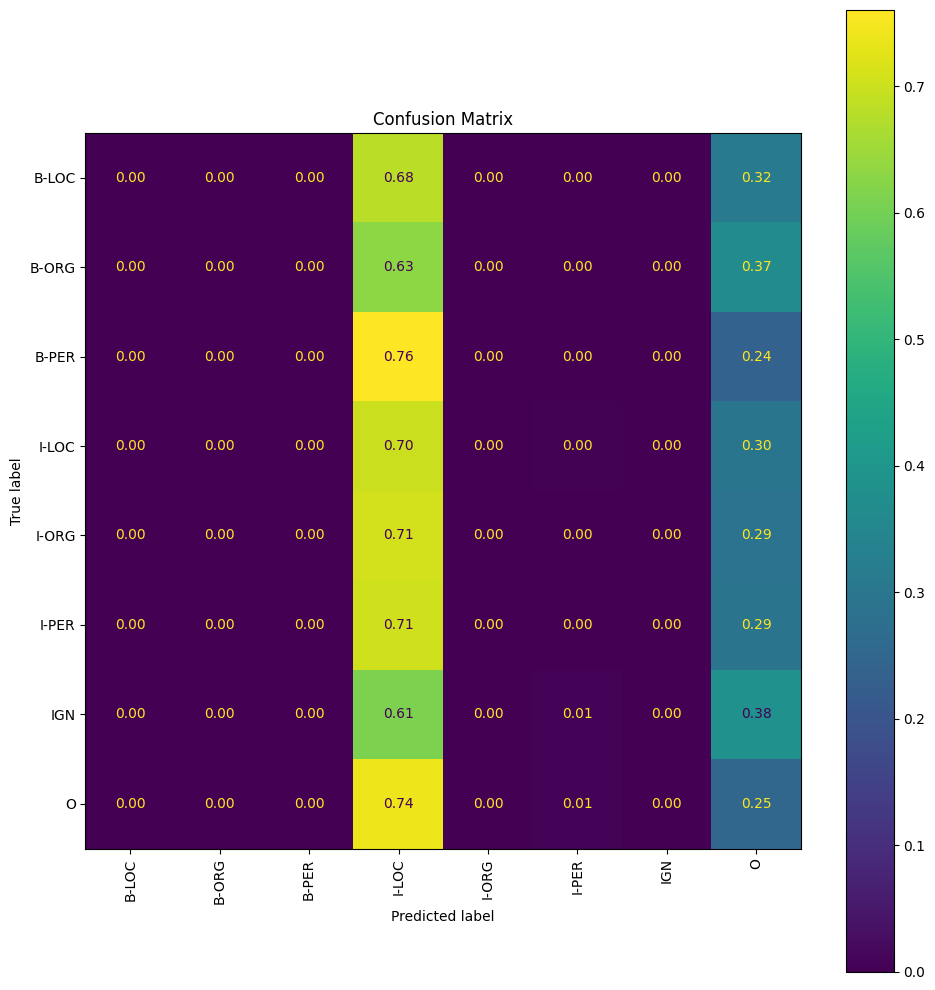

              0         1      2         3      4         5         6      7   \
tokens  ▁Weitere  ▁Version     en    ▁exist  ieren      ▁von      ▁Sid    ney   
labels         O         O    IGN         O    IGN         O     B-PER    IGN   
preds      I-LOC     I-LOC  I-LOC     I-LOC  I-LOC     I-LOC     I-LOC  I-LOC   
losses  1.616025  1.614936    0.0  1.618676    0.0  1.704725  2.122559    0.0   

              8     9   ...     83     84     85        86        87     88  \
tokens       ▁Be  chet  ...     er    spo     on      ▁und       ▁Co      o   
labels     I-PER   IGN  ...    IGN    IGN    IGN         O     B-PER    IGN   
preds          O     O  ...  I-LOC  I-LOC  I-LOC     I-LOC         O  I-LOC   
losses  1.803906   0.0  ...    0.0    0.0    0.0  1.623581  2.042858    0.0   

           89         90        91   92  
tokens    tie  ▁Williams         ▁    .  
labels    IGN      I-PER         O  IGN  
preds   I-LOC      I-LOC     I-LOC    O  
losses    0.0   1.717021  1.66

In [5]:
# =========================
# 4.7 성능 측정
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.nn.functional import cross_entropy
from transformers import (
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    XLMRobertaForTokenClassification,
)

y_true = [["O", "O", "O", "B-MISC", "I-MISC", "O"], ["B-PER", "I-PER", "O"]]
y_pred = [["O", "O", "B-MISC", "I-MISC", "I-MISC", "O"], ["B-PER", "I-PER", "O"]]
print(classification_report(y_true, y_pred))


def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape
    labels_list, preds_list = [], []

    for batch_idx in range(batch_size):
        example_labels, example_preds = [], []
        for seq_idx in range(seq_len):
            if label_ids[batch_idx, seq_idx] != -100:
                example_labels.append(index2tag[label_ids[batch_idx][seq_idx]])
                example_preds.append(index2tag[preds[batch_idx][seq_idx]])
        labels_list.append(example_labels)
        preds_list.append(example_preds)

    return preds_list, labels_list


# =========================
# 4.8 XLM-RoBERTa 미세 튜닝하기
# =========================

num_epochs = 3
batch_size = 24
logging_steps = max(1, len(panx_de_encoded["train"]) // batch_size)
model_name = f"{xlmr_model_name}-finetuned-panx-de"

training_args = TrainingArguments(
    output_dir=model_name,
    log_level="error",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy="epoch",
    save_strategy="no",
    weight_decay=0.01,
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=False,
)

# 필요 시 로그인
# from huggingface_hub import notebook_login
# notebook_login()


def compute_metrics(eval_pred):
    y_pred, y_true = align_predictions(eval_pred.predictions, eval_pred.label_ids)
    return {
        "f1": f1_score(y_true, y_pred),
    }


data_collator = DataCollatorForTokenClassification(xlmr_tokenizer)


def model_init():
    return XLMRobertaForTokenClassification.from_pretrained(
        xlmr_model_name,
        config=xlmr_config,
    ).to(device)


trainer = Trainer(
    model_init=model_init,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    train_dataset=panx_de_encoded["train"],
    eval_dataset=panx_de_encoded["validation"],
    processing_class=xlmr_tokenizer,
)

# 학습이 오래 걸릴 수 있으므로 필요할 때만 실행
# trainer.train()

# trainer.train()을 아직 안 돌렸다면, 아래 tag_text 예시는 기존 모델을 사용
inference_model = trainer.model if trainer.model is not None else xlmr_model

text_de = "Jeff Dean ist ein Informatiker bei Google in Kalifornien"
print(tag_text(text_de, tags, inference_model, xlmr_tokenizer))


# =========================
# 4.9 오류 분석
# =========================

def forward_pass_with_label(batch):
    features = [dict(zip(batch, values)) for values in zip(*batch.values())]
    batch_collated = data_collator(features)

    input_ids = batch_collated["input_ids"].to(device)
    attention_mask = batch_collated["attention_mask"].to(device)
    labels = batch_collated["labels"].to(device)

    with torch.no_grad():
        outputs = trainer.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        num_labels = logits.shape[-1]
        loss = cross_entropy(
            logits.view(-1, num_labels),
            labels.view(-1),
            reduction="none",
            ignore_index=-100,
        )

    loss = loss.view(len(input_ids), -1).cpu().numpy()
    predicted_label = torch.argmax(logits, dim=-1).cpu().numpy()

    return {
        "loss": loss,
        "predicted_label": predicted_label,
    }


valid_set = panx_de_encoded["validation"]
valid_set = valid_set.map(forward_pass_with_label, batched=True, batch_size=32)
df = valid_set.to_pandas()

# 무시 토큰 표시용
index2tag[-100] = "IGN"

df["input_tokens"] = df["input_ids"].apply(
    lambda x: xlmr_tokenizer.convert_ids_to_tokens(x)
)

df["predicted_label"] = df["predicted_label"].apply(
    lambda x: [index2tag[i] for i in x]
)

df["labels"] = df["labels"].apply(
    lambda x: [index2tag[i] for i in x]
)

df["loss"] = df.apply(
    lambda x: x["loss"][: len(x["input_ids"])],
    axis=1,
)

df["predicted_label"] = df.apply(
    lambda x: x["predicted_label"][: len(x["input_ids"])],
    axis=1,
)

df["labels"] = df.apply(
    lambda x: x["labels"][: len(x["input_ids"])],
    axis=1,
)

print(df.head())


df_tokens = df.apply(pd.Series.explode)
df_tokens = df_tokens.reset_index().rename(columns={"index": "sentence_id"})
df_tokens["loss"] = df_tokens["loss"].astype(float).round(2)

print(df_tokens.head())

print(
    df_tokens.groupby("input_tokens")[["loss"]]
    .agg(["count", "mean", "sum"])
    .droplevel(level=0, axis=1)
    .sort_values(by="sum", ascending=False)
    .reset_index()
    .round(2)
    .head(10)
    .T
)

print(
    df_tokens.groupby("labels")[["loss"]]
    .agg(["count", "mean", "sum"])
    .droplevel(level=0, axis=1)
    .sort_values(by="mean", ascending=False)
    .reset_index()
    .round(2)
    .T
)


def plot_confusion_matrix(
    y_true,
    y_pred,
    label_names=None,
    normalize="true",
    figsize=(10, 10),
):
    if label_names is None:
        label_names = sorted(set(y_true) | set(y_pred))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_names,
        normalize=normalize,
    )

    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names,
    )
    disp.plot(ax=ax, xticks_rotation="vertical", values_format=".2f")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


# 실제 데이터에 나타난 라벨 기준으로 축을 맞춤
label_names = sorted(
    set(df_tokens["labels"].tolist()) | set(df_tokens["predicted_label"].tolist())
)

plot_confusion_matrix(
    df_tokens["labels"].tolist(),
    df_tokens["predicted_label"].tolist(),
    label_names=label_names,
)


def get_samples(df):
    for _, row in df.iterrows():
        labels, preds, tokens, losses = [], [], [], []

        for i, _ in enumerate(row["attention_mask"]):
            if i not in (0, len(row["attention_mask"]) - 1):
                labels.append(row["labels"][i])
                preds.append(row["predicted_label"][i])
                tokens.append(row["input_tokens"][i])
                losses.append(float(row["loss"][i]))

        yield pd.DataFrame(
            {
                "tokens": tokens,
                "labels": labels,
                "preds": preds,
                "losses": losses,
            }
        ).T


df["total_loss"] = df["loss"].apply(sum)

df_tmp = df.sort_values(by="total_loss", ascending=False).head(3)
for sample in get_samples(df_tmp):
    print(sample)

df_tmp = df.loc[df["input_tokens"].apply(lambda x: "▁" in x)].head(2)
for sample in get_samples(df_tmp):
    print(sample)

[de] 데이터셋에서 [de] 모델의 F1-점수: 0.009
         0      1      2      3      4            5      6      7        8   \
Tokens  <s>  ▁Jeff    ▁De     an   ▁est  ▁informatic    ien  ▁chez  ▁Google   
Tags      O  I-LOC  I-LOC  I-LOC  I-LOC        I-LOC  I-LOC  I-LOC    I-LOC   

           9      10     11     12    13  
Tokens    ▁en  ▁Cali    for    nie  </s>  
Tags    I-LOC      O  I-LOC  I-LOC     O  


Map:   0%|          | 0/2290 [00:00<?, ? examples/s]

[fr] 데이터셋에서 [de] 모델의 F1-점수: 0.038


[it] 데이터셋에서 [de] 모델의 F1-점수: 0.014


[en] 데이터셋에서 [de] 모델의 F1-점수: 0.009


...

   num_samples  f1_score
0          250  0.038371


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

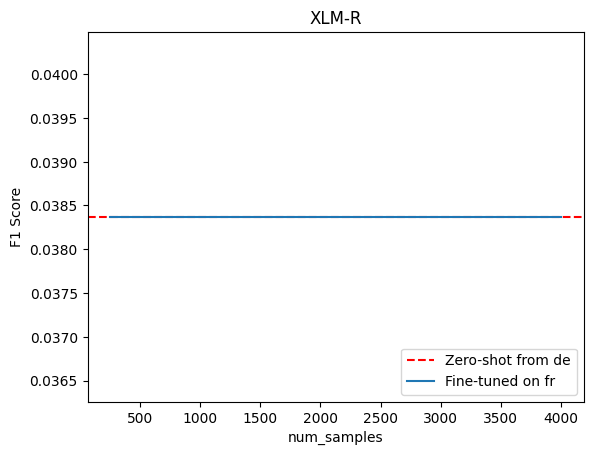

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

[de] 데이터셋에서 [de] 모델의 F1-점수: 0.009
F1(de) = 0.009


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

                   de      fr      it      en
Fine-tuned on                                
de             0.0093  0.0384  0.0136  0.0092
each           0.0093  0.0384  0.0136  0.0092
all            0.0093  0.0384  0.0136  0.0092
4.10 section loaded.


In [7]:
# =========================
# 4.10 교차 언어 전이
# =========================

from collections import defaultdict
from datasets import DatasetDict, concatenate_datasets

def get_f1_score(trainer, dataset):
    metrics = trainer.predict(dataset).metrics
    return metrics["test_f1"]


f1_scores = defaultdict(dict)

# 독일어로 학습한 모델을 독일어 테스트셋에 평가
f1_scores["de"]["de"] = get_f1_score(trainer, panx_de_encoded["test"])
print(f"[de] 데이터셋에서 [de] 모델의 F1-점수: {f1_scores['de']['de']:.3f}")

# 프랑스어 문장 예측 예시
text_fr = "Jeff Dean est informaticien chez Google en Californie"
inference_model = trainer.model if trainer.model is not None else xlmr_model
print(tag_text(text_fr, tags, inference_model, xlmr_tokenizer))


def evaluate_lang_performance(lang, trainer):
    panx_ds = encode_panx_dataset(panx_ch[lang])
    f1_score_val = get_f1_score(trainer, panx_ds["test"])
    print(f"[{lang}] 데이터셋에서 [de] 모델의 F1-점수: {f1_score_val:.3f}")
    return f1_score_val


# 제로샷 성능 평가
f1_scores["de"]["fr"] = evaluate_lang_performance("fr", trainer)
f1_scores["de"]["it"] = evaluate_lang_performance("it", trainer)
f1_scores["de"]["en"] = evaluate_lang_performance("en", trainer)


# =========================
# 4.10.1 제로샷 전이가 유용할 때
# =========================

def train_on_subset(dataset, num_samples, do_train=False):
    train_ds = dataset["train"].shuffle(seed=42).select(range(num_samples))
    valid_ds = dataset["validation"]
    test_ds = dataset["test"]

    training_args.logging_steps = max(1, len(train_ds) // batch_size)

    subset_trainer = Trainer(
        model_init=model_init,
        args=training_args,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        processing_class=xlmr_tokenizer,
    )

    if do_train:
        subset_trainer.train()

    f1 = get_f1_score(subset_trainer, test_ds)

    return pd.DataFrame.from_dict(
        {
            "num_samples": [len(train_ds)],
            "f1_score": [f1],
        }
    )


panx_fr_encoded = encode_panx_dataset(panx_ch["fr"])

training_args.push_to_hub = False

metrics_df = train_on_subset(panx_fr_encoded, 250, do_train=False)
print(metrics_df)

for num_samples in [500, 1000, 2000, 4000]:
    metrics_df = pd.concat(
        [metrics_df, train_on_subset(panx_fr_encoded, num_samples, do_train=False)],
        ignore_index=True,
    )

fig, ax = plt.subplots()
ax.axhline(f1_scores["de"]["fr"], ls="--", color="r")
metrics_df.set_index("num_samples").plot(y="f1_score", ax=ax)
plt.legend(["Zero-shot from de", "Fine-tuned on fr"], loc="lower right")
plt.title("XLM-R")
plt.ylabel("F1 Score")
plt.show()


# =========================
# 4.10.2 다국어에서 동시 미세 튜닝하기
# =========================

def concatenate_splits(corpora):
    multi_corpus = DatasetDict()
    for split in corpora[0].keys():
        multi_corpus[split] = concatenate_datasets(
            [corpus[split] for corpus in corpora]
        ).shuffle(seed=42)
    return multi_corpus


panx_de_fr_encoded = concatenate_splits([panx_de_encoded, panx_fr_encoded])

training_args.logging_steps = max(1, len(panx_de_fr_encoded["train"]) // batch_size)
training_args.push_to_hub = False
training_args.output_dir = "xlm-roberta-base-finetuned-panx-de-fr"

trainer_de_fr = Trainer(
    model_init=model_init,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=xlmr_tokenizer,
    train_dataset=panx_de_fr_encoded["train"],
    eval_dataset=panx_de_encoded["validation"],
)

# 필요할 때만 실행
# trainer_de_fr.train()

for lang in langs:
    f1 = evaluate_lang_performance(lang, trainer_de_fr)
    print(f"F1({lang}) = {f1:.3f}")


# =========================
# 4.10.3 각 언어별 vs 전체 언어 동시 학습 비교
# =========================

corpora = []
for lang in langs[1:]:
    ds_encoded = encode_panx_dataset(panx_ch[lang])
    metrics = train_on_subset(ds_encoded, ds_encoded["train"].num_rows, do_train=False)
    f1_scores[lang][lang] = metrics["f1_score"].iloc[0]
    corpora.append(ds_encoded)

corpora_encoded = concatenate_splits(corpora)
training_args.logging_steps = max(1, len(corpora_encoded["train"]) // batch_size)
training_args.output_dir = "xlm-roberta-base-finetuned-panx-all"
training_args.push_to_hub = False

trainer_all = Trainer(
    model_init=model_init,
    args=training_args,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    processing_class=xlmr_tokenizer,
    train_dataset=corpora_encoded["train"],
    eval_dataset=corpora_encoded["validation"],
)

# 필요할 때만 실행
# trainer_all.train()

for idx, lang in enumerate(langs[1:]):
    f1_scores["all"][lang] = get_f1_score(trainer_all, corpora[idx]["test"])

# de도 포함하고 싶으면 기존 zero-shot 또는 별도 학습값 사용
if "de" not in f1_scores["all"]:
    f1_scores["all"]["de"] = f1_scores["de"]["de"]

scores_data = {
    "de": f1_scores["de"],
    "each": {lang: f1_scores[lang].get(lang, np.nan) for lang in langs},
    "all": f1_scores["all"],
}

f1_scores_df = pd.DataFrame(scores_data).T.round(4)
f1_scores_df.rename_axis("Fine-tuned on", axis="rows", inplace=True)
print(f1_scores_df)


print("4.10 section loaded.")